In [35]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# %matplotlib inline  # se usa para que las graficas se muestren dentro del Notebook de una correcta forma, solo se usa en Jupyter y en Colab


In [36]:
#Se carga el dataset directyamente de internet
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"

df = pd.read_csv(url) #se lee el csv con ayuda de la libreria pandas

In [37]:
df.sample(5) #se muestran 5 filas aleatorias del dataset

df.describe() #muestra el minimo, el maximo, la media y otros datos pertinentes

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [38]:
df = df.drop(['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'TRANSMISSION', 'FUELTYPE',],axis=1) # el drop se usa para el,iniar filas o columnas que no queramos usar o que no sean pertinentes
                                                                                                 # el axis puede seer 1  para borrar columnas virticalmente o 0 para borrar filas horizontalmente


In [39]:
df.corr() # se usa para la correlacion entre features para decidir que columnas borrar o cuales usar para hacer la regresion


,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
ENGINESIZE,1.000000,0.934011,0.832225,0.778746,0.819482,-0.808554,0.874154
CYLINDERS,0.934011,1.000000,0.796473,0.724594,0.776788,-0.770430,0.849685
FUELCONSUMPTION_CITY,0.832225,0.796473,1.000000,0.965718,0.995542,-0.935613,0.898039
FUELCONSUMPTION_HWY,0.778746,0.724594,0.965718,1.000000,0.985804,-0.893809,0.861748
FUELCONSUMPTION_COMB,0.819482,0.776788,0.995542,0.985804,1.000000,-0.927965,0.892129
FUELCONSUMPTION_COMB_MPG,-0.808554,-0.770430,-0.935613,-0.893809,-0.927965,1.000000,-0.906394
CO2EMISSIONS,0.874154,0.849685,0.898039,0.861748,0.892129,-0.906394,1.000000


In [40]:
df.head(9) #muestra las primeras 9 filas desde la cabeza

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2.0,4,9.9,6.7,8.5,33,196
1,2.4,4,11.2,7.7,9.6,29,221
2,1.5,4,6.0,5.8,5.9,48,136
3,3.5,6,12.7,9.1,11.1,25,255
4,3.5,6,12.1,8.7,10.6,27,244
5,3.5,6,11.9,7.7,10.0,28,230
6,3.5,6,11.8,8.1,10.1,28,232
7,3.7,6,12.8,9.0,11.1,25,255
8,3.7,6,13.4,9.5,11.6,24,267


In [42]:
df = df.drop(['CYLINDERS', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY','FUELCONSUMPTION_COMB',],axis=1)

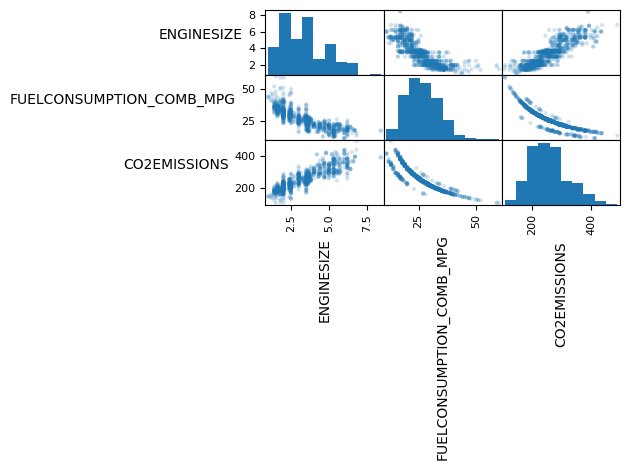

In [43]:
axes = pd.plotting.scatter_matrix(df, alpha=0.2)

for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90) #gira el texto del eje X
    ax.yaxis.label.set_rotation(0)  #deja el eje Y horizontal
    ax.yaxis.label.set_ha('right')  #alinea el texto a la derecha

plt.tight_layout() #organiza automáticamente los espacios, evita que se sobrepongan
plt.gcf().subplots_adjust(wspace=0, hspace=0) # elimina espacios entre gráficos, wspace → espacio horizontal, hspace → espacio vertical
plt.show()


In [57]:
# Toma todas las filas del dataset, usa las primeras dos columnas como entrada (X) y la tercera como salida (y), y conviértelas a formato NumPy
X = df.iloc[:,[0,1]].to_numpy()
y = df.iloc[:,[2]].to_numpy()

In [58]:
# --------------------------------------------
# ESCALADO / NORMALIZACIÓN DE DATOS
# --------------------------------------------
# En Machine Learning es importante que todas las variables
# tengan una escala similar. Esto evita que variables con
# valores más grandes dominen el modelo.

from sklearn import preprocessing

# Se crea un objeto StandardScaler
# Este transformará los datos para que tengan:
# - media = 0
# - desviación estándar = 1
std_scaler = preprocessing.StandardScaler()

# fit_transform hace dos cosas:
# 1. Calcula la media y desviación estándar de cada columna (fit)
# 2. Aplica la transformación a los datos (transform)
X_std = std_scaler.fit_transform(X)

# --------------------------------------------
# VERIFICACIÓN DEL ESCALADO
# --------------------------------------------
# Convertimos a DataFrame solo para visualizar estadísticas
# Esperamos ver:
# - media ≈ 0
# - desviación estándar ≈ 1
pd.DataFrame(X_std).describe().round(2)

,0,1
count,1067.00,1067.00
mean,0.00,-0.00
std,1.00,1.00
min,-1.66,-2.07
25%,-0.95,-0.73
50%,0.04,-0.06
75%,0.67,0.61
max,3.57,4.50


In [60]:
# --------------------------------------------
# DIVISIÓN DE DATOS: ENTRENAMIENTO Y PRUEBA
# --------------------------------------------
# En Machine Learning es necesario dividir los datos en dos partes:
# - Entrenamiento (train): donde el modelo aprende
# - Prueba (test): donde se evalúa el modelo

from sklearn.model_selection import train_test_split

# Se dividen los datos:
# X_std -> variables de entrada (features)
# y     -> variable objetivo (target)

# test_size=0.2 significa que el 20% de los datos se usarán para prueba
# random_state=42 asegura que la división sea siempre la misma (reproducibilidad)

X_train, X_test, y_train, y_test = train_test_split(
    X_std, y, test_size=0.2, random_state=42
)

# --------------------------------------------
# RESULTADO DE LA DIVISIÓN
# --------------------------------------------
# X_train: datos de entrada para entrenar el modelo
# X_test: datos de entrada para probar el modelo
# y_train: valores reales para entrenar
# y_test: valores reales para evaluar

#verificar tamaños:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (853, 2)
X_test shape: (214, 2)
y_train shape: (853, 1)
y_test shape: (214, 1)


In [61]:
# --------------------------------------------
# CONSTRUCCIÓN DEL MODELO DE REGRESIÓN LINEAL MÚLTIPLE
# --------------------------------------------
# En este paso se crea y entrena un modelo de Machine Learning
# que aprende la relación entre las variables de entrada (X)
# y la variable objetivo (y)

from sklearn import linear_model

# --------------------------------------------
# CREACIÓN DEL MODELO
# --------------------------------------------
# Se crea un objeto de regresión lineal
# Este modelo intentará ajustar una ecuación del tipo:
# y = b + m1*x1 + m2*x2
regressor = linear_model.LinearRegression()

# --------------------------------------------
# ENTRENAMIENTO DEL MODELO
# --------------------------------------------
# El modelo aprende a partir de los datos de entrenamiento
# X_train -> variables de entrada
# y_train -> valores reales
regressor.fit(X_train, y_train)

# --------------------------------------------
# OBTENCIÓN DE PARÁMETROS DEL MODELO
# --------------------------------------------

# coef_ contiene los coeficientes (pendientes)
# indican cuánto influye cada variable en la predicción
coef_ = regressor.coef_

# intercept_ es el valor base cuando todas las variables son 0
intercept_ = regressor.intercept_

# Mostrar resultados
print("Coeficientes:", coef_)
print("Intercepto:", intercept_)

# --------------------------------------------
# INTERPRETACIÓN
# --------------------------------------------
# El modelo aprendido tiene la forma:
# y = intercepto + coef1*x1 + coef2*x2
#
# Donde:
# - x1, x2 son las variables de entrada
# - coef1, coef2 indican la importancia de cada variable

Coeficientes: [[ 25.27339614 -37.4381472 ]]
Intercepto: [256.29072488]


In [62]:
# --------------------------------------------
# CONVERSIÓN DE COEFICIENTES A ESCALA ORIGINAL
# --------------------------------------------
# El modelo fue entrenado con datos escalados (normalizados),
# por lo tanto los coeficientes obtenidos están en esa escala.
# Para interpretarlos correctamente, debemos convertirlos
# de vuelta a la escala original de los datos.

# Obtener la media de cada variable usada en el escalado
means_ = std_scaler.mean_

# Obtener la desviación estándar (raíz de la varianza)
std_devs_ = np.sqrt(std_scaler.var_)

# --------------------------------------------
# AJUSTE DE LOS COEFICIENTES
# --------------------------------------------
# Se ajustan los coeficientes dividiéndolos por la desviación estándar
# Esto devuelve los coeficientes a la escala original
coef_original = coef_ / std_devs_

# --------------------------------------------
# AJUSTE DEL INTERCEPTO
# --------------------------------------------
# Se corrige el intercepto teniendo en cuenta el escalado aplicado
# Esto asegura que el modelo sea correcto en el espacio original
intercept_original = intercept_ - np.sum((means_ * coef_) / std_devs_)

# --------------------------------------------
# RESULTADOS FINALES INTERPRETABLES
# --------------------------------------------
print("Coeficientes en escala original:", coef_original)
print("Intercepto en escala original:", intercept_original)

# --------------------------------------------
# INTERPRETACIÓN
# --------------------------------------------
# Ahora el modelo se puede expresar como:
# y = intercepto + coef1*x1 + coef2*x2
#
# Donde:
# - los coeficientes están en unidades reales
# - se puede interpretar cuánto influye cada variable

Coeficientes en escala original: [[17.8581369  -5.01502179]]
Intercepto en escala original: [329.1363967]


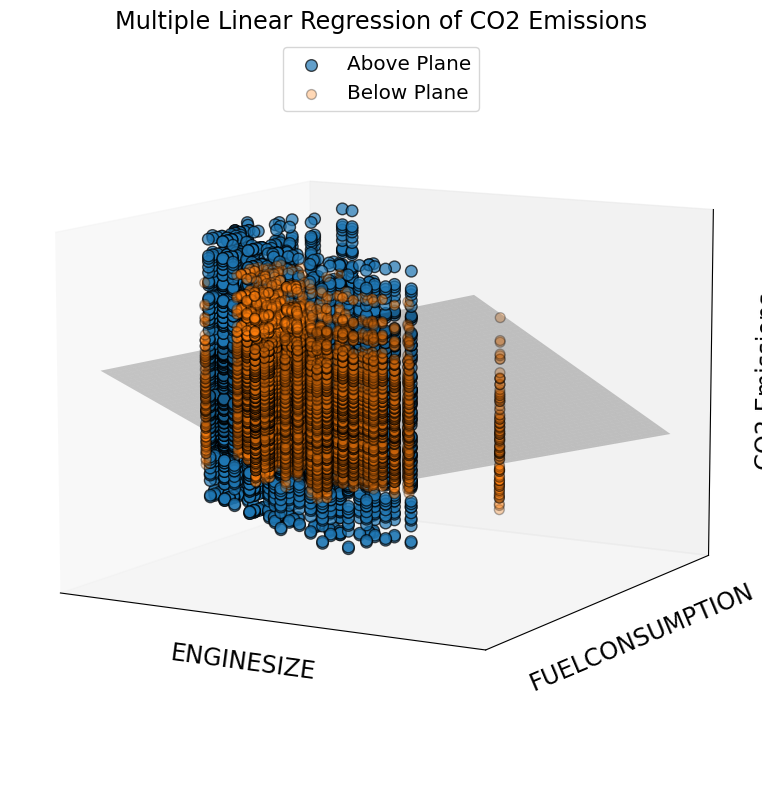

In [63]:
# --------------------------------------------
# VISUALIZACIÓN 3D DEL MODELO DE REGRESIÓN
# --------------------------------------------
# Este bloque crea una gráfica 3D que muestra:
# - los datos reales
# - el plano de regresión aprendido por el modelo

# --------------------------------------------
# PREPARACIÓN DE DATOS
# --------------------------------------------
# Se asegura que X_test tenga la forma correcta
# para poder trabajar en 3D

X1 = X_test[:, 0] if X_test.ndim > 1 else X_test
X2 = X_test[:, 1] if X_test.ndim > 1 else np.zeros_like(X1)

# --------------------------------------------
# CREACIÓN DE LA SUPERFICIE (PLANO)
# --------------------------------------------
# Se genera una malla de puntos en el espacio X1-X2

x1_surf, x2_surf = np.meshgrid(
    np.linspace(X1.min(), X1.max(), 100),
    np.linspace(X2.min(), X2.max(), 100)
)

# Se calcula el valor de y para cada punto de la malla
# usando la ecuación del modelo
y_surf = intercept_ + coef_[0, 0] * x1_surf + coef_[0, 1] * x2_surf

# --------------------------------------------
# PREDICCIONES DEL MODELO
# --------------------------------------------
# Se generan predicciones para los datos de prueba
y_pred = regressor.predict(X_test.reshape(-1, 1)) if X_test.ndim == 1 else regressor.predict(X_test)

# --------------------------------------------
# CLASIFICACIÓN DE PUNTOS
# --------------------------------------------
# Se separan los puntos que están por encima o por debajo del plano

above_plane = y_test >= y_pred
below_plane = y_test < y_pred

# Ajuste de forma (de 2D a 1D)
above_plane = above_plane[:, 0]
below_plane = below_plane[:, 0]

# --------------------------------------------
# CREACIÓN DE LA GRÁFICA 3D
# --------------------------------------------
fig = plt.figure(figsize=(20, 8))
ax = fig.add_subplot(111, projection='3d')

# --------------------------------------------
# GRAFICAR LOS PUNTOS
# --------------------------------------------
# Puntos por encima del plano
ax.scatter(X1[above_plane], X2[above_plane], y_test[above_plane],
           label="Above Plane", s=70, alpha=0.7, ec='k')

# Puntos por debajo del plano
ax.scatter(X1[below_plane], X2[below_plane], y_test[below_plane],
           label="Below Plane", s=50, alpha=0.3, ec='k')

# --------------------------------------------
# GRAFICAR EL PLANO DE REGRESIÓN
# --------------------------------------------
ax.plot_surface(x1_surf, x2_surf, y_surf, color='k', alpha=0.21)

# --------------------------------------------
# CONFIGURACIÓN VISUAL
# --------------------------------------------
ax.view_init(elev=10)  # ángulo de visualización

ax.legend(fontsize='x-large', loc='upper center')

# Se eliminan ticks para limpiar la gráfica
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

# Etiquetas de los ejes
ax.set_xlabel('ENGINESIZE', fontsize='xx-large')
ax.set_ylabel('FUELCONSUMPTION', fontsize='xx-large')
ax.set_zlabel('CO2 Emissions', fontsize='xx-large')

# Título
ax.set_title('Multiple Linear Regression of CO2 Emissions', fontsize='xx-large')

plt.tight_layout()
plt.show()

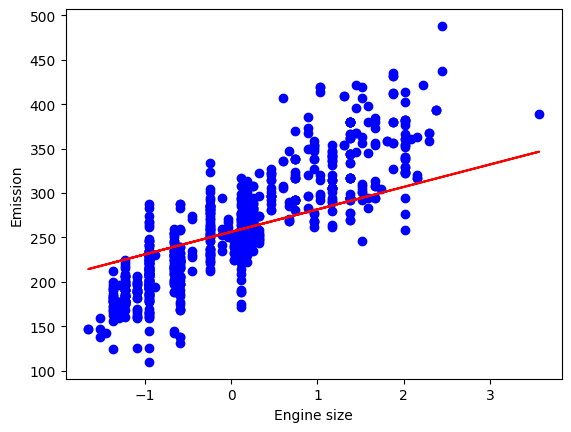

In [50]:
plt.scatter(X_train[:,0], y_train,  color='blue')
plt.plot(X_train[:,0], coef_[0,0] * X_train[:,0] + intercept_[0], '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

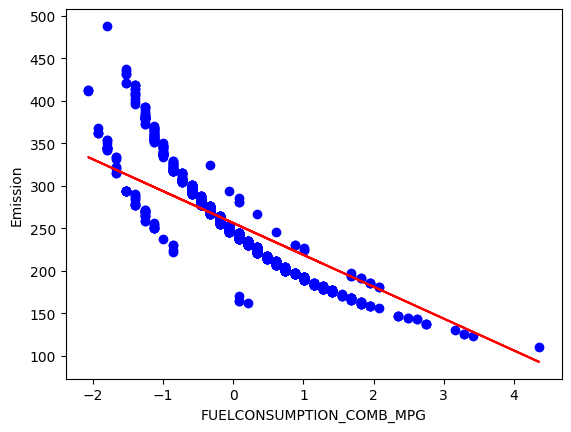

In [51]:
plt.scatter(X_train[:,1], y_train,  color='blue')
plt.plot(X_train[:,1], coef_[0,1] * X_train[:,1] + intercept_[0], '-r')
plt.xlabel("FUELCONSUMPTION_COMB_MPG")
plt.ylabel("Emission")
plt.show()

In [52]:
X_train_1 = X_train[:,0]
regressor_1 = linear_model.LinearRegression()
regressor_1.fit(X_train_1.reshape(-1, 1), y_train)
coef_1 =  regressor_1.coef_
intercept_1 = regressor_1.intercept_
print ('Coefficients: ',coef_1)
print ('Intercept: ',intercept_1)

Coefficients:  [[55.18408797]]
Intercept:  [256.77183014]


Text(0, 0.5, 'Emission')

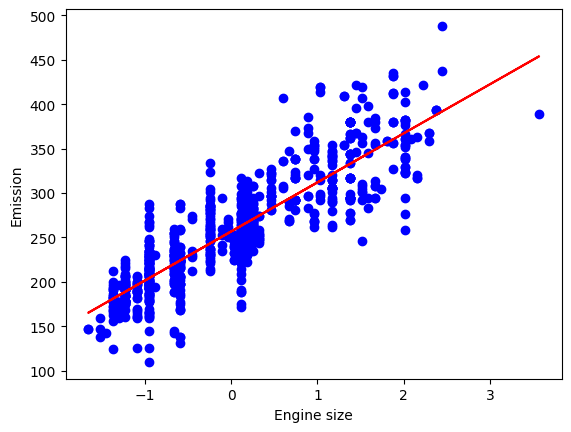

In [53]:
plt.scatter(X_train_1, y_train,  color='blue')
plt.plot(X_train_1, coef_1[0] * X_train_1 + intercept_1, '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")


Text(0, 0.5, 'CO2 Emission')

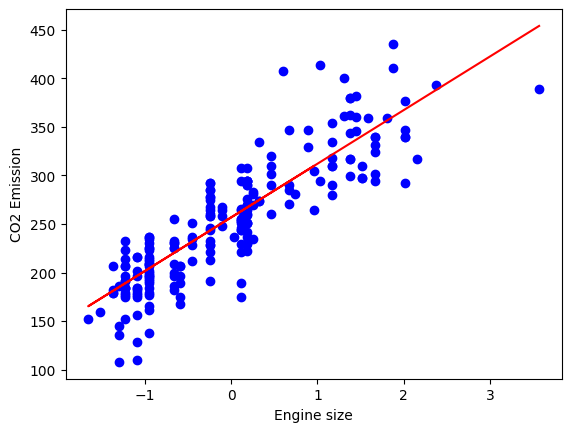

In [54]:
X_test_1 = X_test[:,0]
plt.scatter(X_test_1, y_test,  color='blue')
plt.plot(X_test_1, coef_1[0] * X_test_1 + intercept_1, '-r')
plt.xlabel("Engine size")
plt.ylabel("CO2 Emission")

In [55]:
X_train_2 = X_train[:,1]
regressor_2 = linear_model.LinearRegression()
regressor_2.fit(X_train_2.reshape(-1, 1), y_train)
coef_2 =  regressor_2.coef_
intercept_2 = regressor_2.intercept_
print ('Coefficients: ',coef_2)
print ('Intercept: ',intercept_2)

Coefficients:  [[-58.51827989]]
Intercept:  [256.09392179]


Text(0, 0.5, 'CO2 Emission')

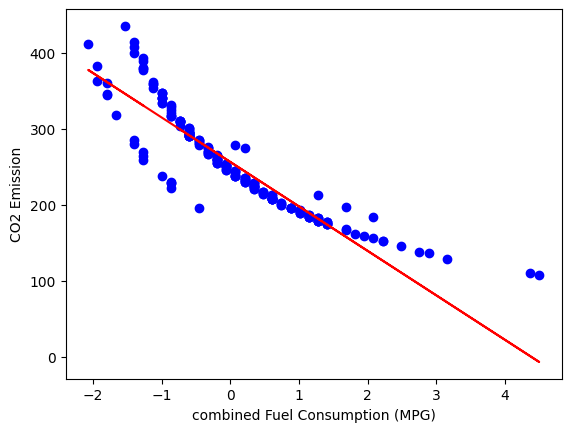

In [56]:
X_test_2 = X_test[:,1]
plt.scatter(X_test_2, y_test,  color='blue')
plt.plot(X_test_2, coef_2[0] * X_test_2 + intercept_2, '-r')
plt.xlabel("combined Fuel Consumption (MPG)")
plt.ylabel("CO2 Emission")